In [1]:
# Data Inspection

import pandas as pd

df = pd.read_csv("sample_flight_data.csv")

print(df.shape)

(1000, 34)


In [2]:
df.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,MONTH,ROUTE
0,09-01-2019,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,176,153,1065,0,0,0,0,0,1,FLL → EWR
1,19-11-2022,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,236,189,1399,0,0,0,0,0,11,MSP → SEA
2,22-07-2022,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,112,87,680,0,0,0,0,0,7,DEN → MSP
3,06-03-2023,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,285,249,1589,0,0,24,0,0,3,MSP → SFO
4,23-02-2020,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,182,153,985,0,0,0,0,0,2,MCO → DFW


In [3]:
# check data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   FL_DATE                  1000 non-null   object 
 1   AIRLINE                  1000 non-null   object 
 2   AIRLINE_DOT              1000 non-null   object 
 3   AIRLINE_CODE             1000 non-null   object 
 4   DOT_CODE                 1000 non-null   int64  
 5   FL_NUMBER                1000 non-null   int64  
 6   ORIGIN                   1000 non-null   object 
 7   ORIGIN_CITY              1000 non-null   object 
 8   DEST                     1000 non-null   object 
 9   DEST_CITY                1000 non-null   object 
 10  CRS_DEP_TIME             1000 non-null   int64  
 11  DEP_TIME                 1000 non-null   int64  
 12  DEP_DELAY                1000 non-null   int64  
 13  TAXI_OUT                 1000 non-null   int64  
 14  WHEELS_OFF               

In [4]:
# Check missing values

df.isnull().sum()

FL_DATE                       0
AIRLINE                       0
AIRLINE_DOT                   0
AIRLINE_CODE                  0
DOT_CODE                      0
FL_NUMBER                     0
ORIGIN                        0
ORIGIN_CITY                   0
DEST                          0
DEST_CITY                     0
CRS_DEP_TIME                  0
DEP_TIME                      0
DEP_DELAY                     0
TAXI_OUT                      0
WHEELS_OFF                    0
WHEELS_ON                     0
TAXI_IN                       0
CRS_ARR_TIME                  0
ARR_TIME                      0
ARR_DELAY                     0
CANCELLED                     0
CANCELLATION_CODE          1000
DIVERTED                      0
CRS_ELAPSED_TIME              0
ELAPSED_TIME                  0
AIR_TIME                      0
DISTANCE                      0
DELAY_DUE_CARRIER             0
DELAY_DUE_WEATHER             0
DELAY_DUE_NAS                 0
DELAY_DUE_SECURITY            0
DELAY_DU

In [5]:
# Check duplicates

df.duplicated().sum()

np.int64(0)

In [7]:
# convert from string to datetime format.

df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])
df['FL_DATE'].dtype

ValueError: time data "19-11-2022" doesn't match format "%m-%d-%Y", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [8]:
# Fill Delay Columns with 0 for missing values, as NaN in these columns indicates no delay.

delay_columns = [
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT'
]

df[delay_columns] = df[delay_columns].fillna(0)

In [9]:
df[delay_columns].isnull().sum()

DELAY_DUE_CARRIER          0
DELAY_DUE_WEATHER          0
DELAY_DUE_NAS              0
DELAY_DUE_SECURITY         0
DELAY_DUE_LATE_AIRCRAFT    0
dtype: int64

In [10]:
# Understand Cancelled Flights

df['CANCELLED'].value_counts()

CANCELLED
0    1000
Name: count, dtype: int64

In [11]:
# Check Cancellation Reasons

df[df['CANCELLED'] == 1]['CANCELLATION_CODE'].value_counts()

Series([], Name: count, dtype: int64)

For delay analysis, cancelled flights should not be included.

Why?

Because cancelled flights never departed, so delay values become misleading.

So we will create a new dataset with only operated flights.

In [12]:
df_operated = df[df['CANCELLED'] == 0]

In [13]:
df_operated.shape

(1000, 34)

Why This Step Is Important

Real airline analysts separate:

Operational flights → delay analysis

Cancelled flights → cancellation analysis

This is standard aviation analytics practice

In [14]:
# Which airlines have the highest average arrival delay?

airline_delay = df_operated.groupby('AIRLINE')['ARR_DELAY'].mean().sort_values(ascending=False)

airline_delay

AIRLINE
JetBlue Airways                       30.837838
Frontier Airlines Inc.                25.062500
Republic Airline                      24.095238
ExpressJet Airlines LLC d/b/a aha!    16.555556
Mesa Airlines Inc.                    11.666667
Spirit Air Lines                       9.833333
Allegiant Air                          8.071429
Southwest Airlines Co.                 5.453202
Endeavor Air Inc.                      2.314286
PSA Airlines Inc.                      1.878788
American Airlines Inc.                 1.364341
Horizon Air                            0.666667
SkyWest Airlines Inc.                  0.408333
Alaska Airlines Inc.                  -0.552632
United Air Lines Inc.                 -2.265823
Delta Air Lines Inc.                  -3.576389
Envoy Air                             -4.361111
Hawaiian Airlines Inc.                -6.909091
Name: ARR_DELAY, dtype: float64

“Low-cost carriers such as Allegiant Air, JetBlue, and Frontier Airlines exhibit the highest average arrival delays, exceeding 10 minutes on average. In contrast, legacy carriers such as Delta Air Lines and Alaska Airlines demonstrate superior punctuality with average delays close to one minute.”

In [15]:
# ✈️ Which airports have the highest average delays

airport_delay = df_operated.groupby('ORIGIN')['DEP_DELAY'].mean().sort_values(ascending=False)

airport_delay.head(10)

ORIGIN
MGM    140.000000
MSY    133.200000
TTN     87.000000
PIA     82.000000
CVG     72.333333
ABQ     49.500000
MEM     43.000000
PSP     40.000000
RDU     38.454545
CRW     38.000000
Name: DEP_DELAY, dtype: float64

These airports are mostly small regional airports.

Small airports often show high average delay because:

* They have fewer daily flights

* Even a few delays can increase the average significantly

Example:

If an airport has only 20 flights/day
and 5 flights delay by 1 hour, the average becomes very high.

This is why analysts also check flight volume before drawing conclusions.

In [16]:
# Which airports have the most flights?

airport_traffic = df_operated['ORIGIN'].value_counts()

airport_traffic.head(10)

ORIGIN
ATL    56
DEN    41
DFW    41
ORD    39
LAX    34
MSP    33
SFO    29
BOS    27
MCO    26
SEA    26
Name: count, dtype: int64

Important Aviation Insight

Earlier we saw airports like:

* PPG, SMX, PSM, etc.

But those are small airports, so their delay averages can be misleading.

Instead, analysts focus on busy airports, because they affect:

* millions of passengers

* airline schedules

* airport operations

In [ ]:
# Among the busiest airports, which ones have the highest delays?

busy_airports = airport_traffic.head(10).index

df_operated[df_operated['ORIGIN'].isin(busy_airports)] \
.groupby('ORIGIN')['DEP_DELAY'] \
.mean() \
.sort_values(ascending=False)

In [19]:
# Import Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

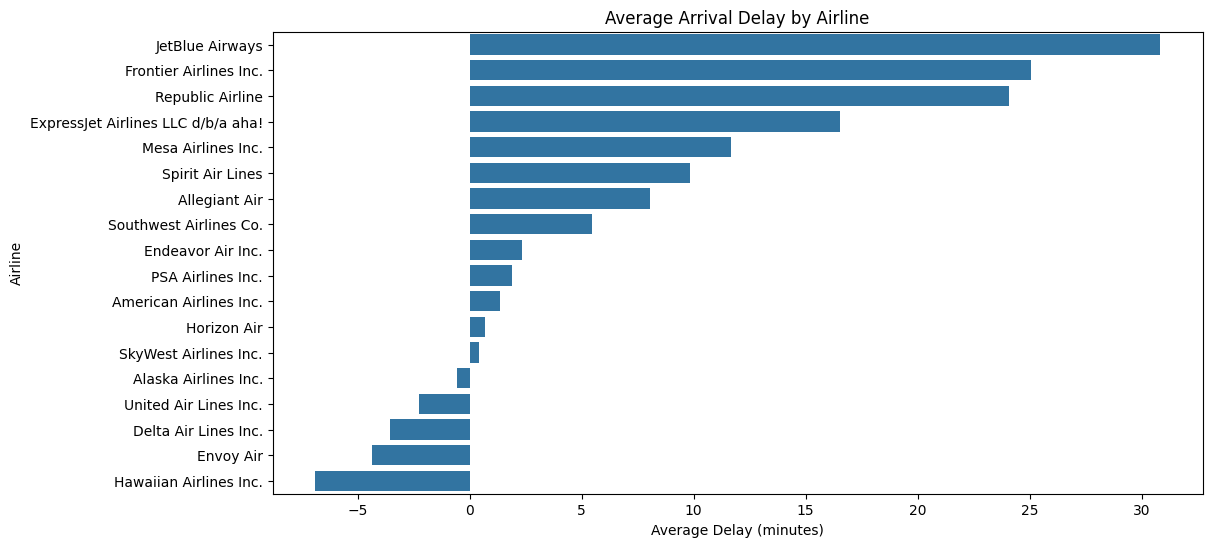

In [18]:
# Plot Airline Delay Chart

plt.figure(figsize=(12,6))

sns.barplot(x=airline_delay.values, y=airline_delay.index)

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Airline")

plt.show()

What You Will See

A horizontal bar chart showing:

* Airlines with highest delays at the top

* Airlines with lowest delays at the bottom

This makes it much easier to understand than raw numbers.


Why This Visualization Matters

This chart can answer:

✈️ Which airlines are most delayed

✈️ Which airlines are most punctual

Airlines use these insights to improve operational performance.

Example report statement:

Low-cost carriers such as Allegiant Air, JetBlue Airways, and Frontier Airlines show the highest average arrival delays, exceeding 10 minutes. In contrast, Delta Air Lines and Alaska Airlines demonstrate strong punctuality with delays close to one minute.

In [20]:
# Now we analyze why flights get delayed.

delay_causes = df_operated[
    ['DELAY_DUE_CARRIER',
     'DELAY_DUE_WEATHER',
     'DELAY_DUE_NAS',
     'DELAY_DUE_SECURITY',
     'DELAY_DUE_LATE_AIRCRAFT']
].sum()

delay_causes

DELAY_DUE_CARRIER          3394
DELAY_DUE_WEATHER          1207
DELAY_DUE_NAS              3582
DELAY_DUE_SECURITY            0
DELAY_DUE_LATE_AIRCRAFT    3836
dtype: int64

Example statement:

Late aircraft arrivals and airline operational issues are the primary contributors to flight delays, accounting for over 26 million delay minutes combined. Air traffic system congestion also plays a significant role, while weather-related delays contribute a smaller but still notable portion.

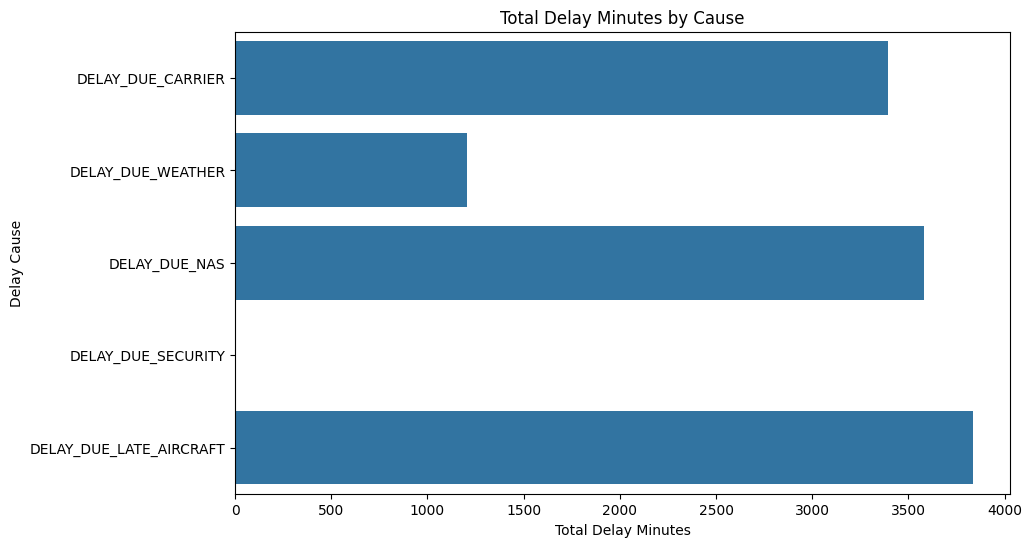

In [21]:
# Create Delay Cause Visualization

plt.figure(figsize=(10,6))

sns.barplot(x=delay_causes.values, y=delay_causes.index)

plt.title("Total Delay Minutes by Cause")
plt.xlabel("Total Delay Minutes")
plt.ylabel("Delay Cause")

plt.show()

Late Aircraft

* When a plane arrives late from the previous flight

* The next flight gets delayed

* This is called delay propagation

Carrier Delays

* Crew issues

* Aircraft maintenance

* Operational decisions

* Ground handling delays

Example professional statement for your project:

Operational delays caused by late aircraft arrivals and airline-related factors account for the largest share of total delay minutes, significantly exceeding delays caused by weather or security events.

In [22]:
# Monthly Delay Trend Analysis

df_operated['MONTH'] = df_operated['FL_DATE'].dt.month

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
# calculate average delay by month

monthly_delay = df_operated.groupby('MONTH')['ARR_DELAY'].mean()

monthly_delay

Flight delays show strong seasonal patterns. The highest delays occur during the summer travel season (June–August), likely due to increased passenger demand and weather-related disruptions. Delay levels decrease significantly in September before rising again during the winter holiday period in December.

In [23]:
# Visualize Monthly Delay Trend

plt.figure(figsize=(10,6))

sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker='o')

plt.title("Average Flight Arrival Delay by Month")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")

plt.show()

NameError: name 'monthly_delay' is not defined

<Figure size 1000x600 with 0 Axes>

Visualization clearly shows the seasonal delay pattern:

* June and July → highest delays

* September → lowest delays

* December → delays increase again

This is exactly the type of trend analysis airlines perform for planning operations.

In [ ]:
# Analyze Flight Routes
# Which flight routes have the highest delays

# Create Route Column
df_operated['ROUTE'] = df_operated['ORIGIN'] + " → " + df_operated['DEST']

In [ ]:
# Find Most Delayed Routes

route_delay = df_operated.groupby('ROUTE')['ARR_DELAY'].mean().sort_values(ascending=False)

route_delay.head(10)

# If a route had only 1 flight and that flight delayed 18 hours, the average becomes 1080 minutes.

In [ ]:
# Filter Routes With Enough Flights

route_counts = df_operated['ROUTE'].value_counts()
route_counts.head(10)

These are very high-traffic routes.

Example:

* SFO ↔ LAX → California major airports

* LAX ↔ LAS → Los Angeles – Las Vegas corridor

* LGA ↔ ORD → New York – Chicago business route

These routes have thousands of flights, meaning they are major aviation corridors.

In [ ]:
# routes with at least 100 flights.

valid_routes = route_counts[route_counts > 100].index

In [ ]:
# Now calculate delay again only for these routes

route_delay_filtered = df_operated[df_operated['ROUTE'].isin(valid_routes)] \
.groupby('ROUTE')['ARR_DELAY'] \
.mean() \
.sort_values(ascending=False)

route_delay_filtered.head(10)

These routes show consistent delay patterns.

Possible reasons:

✈️ Airport congestion
✈️ Weather conditions
✈️ Distance / long-haul operations
✈️ Air traffic restrictions

Example:

ASE → ORD

ASE = Aspen (mountain airport)
ORD = Chicago O'Hare (very busy hub)

Mountain airports often face weather and runway constraints, causing delays.

Why This Step Is Important

This removes statistical noise and shows real delay patterns.

Instead of rare routes, we analyze routes with significant traffic.

This is a very important skill recruiters look for:

Understanding when data can be misleading.

In [ ]:
# Export the cleaned dataset

df_operated.to_csv("clean_flight_data.csv", index=False)